# Домашнее задание №1. Компьютерный практкум 3.

Фракталы: Вариант 5. Печенин Данила Михайлович БПМ233.

In [119]:
import numpy as np
from numba import njit, prange
import holoviews as hv
from holoviews import opts
from holoviews.streams import RangeXY
from functools import partial

In [120]:
# сразу избавимся от расчетов с комплексными числами, чтобы numba могла работать быстрее
@njit(inline='always') # параметр указали, чтобы функция вставлялась на место вызова. Это может сэкономить время на вызов функции.
def julia_point(z_r: float, z_i: float, c_r: float, c_i: float, max_iter: int, escape_radius: float) -> int:
    """
    Вычисляет количество итераций до выхода за пределы escape_radius для точки z = z_r + i*z_i
    для фрактала Жюлиа: z_{n+1} = z_n^3 + z_n + c, где c = c_r + i*c_i.
    
    Params:
    -------
        z_r, z_i : float
            Действительная и мнимая части начальной точки z.
        c_r, c_i : float
            Действительная и мнимая части параметра c.
        max_iter : int
            Максимальное количество итераций, после которого считается, что точка не уходит в бесконечность.
        escape_radius : float
            Радиус, после которого считается, что точка уходит в бесконечность.

    Returns:
    --------
        int
            Количество итераций до выхода за пределы escape_radius.
    """
    escape_radius2 = escape_radius * escape_radius

    for i in range(max_iter):
        z_r2 = z_r * z_r - z_i * z_i
        z_i2 = 2 * z_r * z_i
        z_r3 = z_r2 * z_r - z_i2 * z_i
        z_i3 = z_r2 * z_i + z_i2 * z_r

        z_r_new = z_r3 + z_r + c_r
        z_i_new = z_i3 + z_i + c_i

        z_r, z_i = z_r_new, z_i_new

        if z_r * z_r + z_i * z_i > escape_radius2:
            return i
    
    return max_iter

In [121]:
@njit(parallel=True, boundscheck=False)
def julia_parallel(x_min: float, x_max: float, y_min: float, y_max: float, n_x: int, n_y: int, 
                    c_r: float, c_i: float, max_iter: int, escape_radius: float) -> np.ndarray:
    """
    Параллельный расчет фрактала Жюлиа на сетке размером (n_x, n_y) в области [x_min, x_max] x [y_min, y_max].

    Params:
    -------
        x_min, x_max : float
            Границы области по оси x (действительная ось).
        y_min, y_max : float
            Границы области по оси y (мнимая ось).
        n_x, n_y : int
            Количество точек в сетке по осям x и y соответсвенно.
        c_r, c_i : float
            Действительная и мнимая части параметра c.
        max_iter : int
        max_iter : int
            Максимальное количество итераций, после которого считается, что точка не уходит в бесконечность.
        escape_radius : float
            Радиус, после которого считается, что точка уходит в бесконечность.

    Returns:
    --------
        np.ndarray
            2D массив с количеством итераций до выхода за пределы escape_radius для каждой точки сетки.
    """
    d_x = (x_max - x_min) / n_x
    d_y = (y_max - y_min) / n_y
    lambdas = np.empty((n_y + 1, n_x + 1), dtype=np.uint16)

    for i_y in prange(n_y + 1):
        y = y_min + i_y * d_y
        for i_x in range(n_x + 1):
            x = x_min + i_x * d_x
            lambdas[i_y, i_x] = julia_point(x, y, c_r, c_i, max_iter, escape_radius)

    return lambdas

In [122]:
# запустим функцию один раз для того, чтобы скомпилировать её и в дальнейшем не было задержек при первом вызове
_ = julia_parallel(-0.1, 0.1, -0.1, 0.1, 10, 10, 0.0, 0.0, 100, 2.0)

In [123]:
def get_fractal(x_range, y_range, img_width, img_height, c_r, c_i, max_iter, escape_radius):
    """
    Вычисляет и возвращает фрактал Жюлиа в виде объекта holoviews.Image.

    Params:
    -------
        x_range, y_range : tuple(float, float)
            Кортеж с границами области по оси x (действительная ось) и y (мнимая ось) соответсвенно.
        img_width, img_height : int
            Размер изображения в пикселях по осям x (действительная ось) и y (мнимая ось) соответственно.
        c_r, c_i : float
            Действительная и мнимая части параметра c.
        max_iter : int
            Максимальное количество итераций, после которого считается, что точка не уходит в бесконечность.
        escape_radius : float
            Радиус, после которого считается, что точка уходит в бесконечность.

    Returns:
    --------
        hv.Image
            Объект holoviews.Image с рассчитанным фракталом Жюлиа.
    """
    x_min, x_max = x_range
    y_min, y_max = y_range 
    arr = julia_parallel(x_min, x_max, -y_max, -y_min, img_width, img_height, c_r, c_i, max_iter, escape_radius)
    return hv.Image(arr, bounds=(x_min, y_min, x_max, y_max))

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
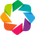

In [133]:
hv.extension('bokeh') 

range_stream = RangeXY(
    x_range=(-1.5, 1.5),
    y_range=(-1.5, 1.5)
)
img_width = 1000
img_height = 1000
c_r, c_i = 0.0, 0.0
max_iter = 1000
escape_radius = 20.0

In [134]:
%%timeit
# посмотрим сколько времени занимает обновление карты при данных параметрах 
_ = get_fractal(range_stream.x_range, range_stream.y_range, img_width, img_height, c_r, c_i, max_iter, escape_radius)

426 ms ± 17 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


С таким количеством итераций укладываемся в секунду на перестроение карты.

In [135]:
dmap = hv.DynamicMap(
    partial(
        get_fractal,
        img_width=img_width,
        img_height=img_height,
        c_r=c_r,
        c_i=c_i,
        max_iter=max_iter,
        escape_radius=escape_radius
    ),
    streams=[range_stream]
)

dmap.opts(
    opts.Image(
        cmap='inferno',
        logz=True,
        height=img_height,
        width=img_width
    )
)

:DynamicMap   []
   :Image   [x,y]   (z)

Примеры 3х различных изображений: 

![](https://raw.githubusercontent.com/dpechenin/cp3_hw/refs/heads/main/hw1/1.png)

![](https://raw.githubusercontent.com/dpechenin/cp3_hw/refs/heads/main/hw1/2.png)

![](https://raw.githubusercontent.com/dpechenin/cp3_hw/refs/heads/main/hw1/3.png)